# **SED CALIB**

Tests on a sed library with one degree of freedom: alpha (normalisation).

## **0. Initialisation**

### 0.1 Packages

In [1]:
### Libs ###
from imports import *

#custom
from src.download_bt_spectra import download_bt_spectra
import src.data_manipulations as dm; reload(dm)
import src.plot_tools as pt; reload(pt)
import src.photometry_errors as pe; reload(pe)
from src.format_to_dat import format_to_lephareinput 

#lephare
import lephare as lp
config = lp.default_stargal_config.copy()

base_dir = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(base_dir)

%matplotlib inline

LEPHAREDIR is being set to the default cache directory:
/home/hallouin/.cache/lephare/data
More than 1Gb may be written there.
LEPHAREWORK is being set to the default cache directory:
/home/hallouin/.cache/lephare/work
Default work cache is already linked. 
This is linked to the run directory:
/home/hallouin/.cache/lephare/runs/20251013T115331


### 0.2 Important inputs

In [2]:
n_sources = 20000 # Number of sources per template to sample
max_row_lephare = 100000 # Number of rows to loop on with zphota
work_with_absmags = True # If true, mag_obs --> mag_obs - deltam
return_dm = True # return dm in mock table
if work_with_absmags == True: #must be true in this case
    return_dm = True


#physical quantities of seds to download.
#WARNING: The number of seds downloaded is equal to len(teff_values) x len(logg_values) x len(metallicity_values), 
#so it could take a lot of space!
teff_values = 5200 #values of simulated sed surface temperature, or list of 
logg_values = 3 #values of simulated sed surface gravity, or list of 
metallicity_values = 0 #values of simulated sed metallicity, or list of 

#if true, delete temporary files
clean_cache = True #lephare sedlib and maglib cache
clean_seds = False #local directory seds

### 0.3 Download spectra

Use ``download_bt_spectra.py``

In [3]:
#--- Downloading parameters--- 
#model
MODEL = "bt-nextgen-agss2009"
BASE_URL = f"https://svo2.cab.inta-csic.es/theory/newov2/ssap.php?model={MODEL}" #website to download from

#dl directory
sed_name = f"Teff{teff_values}logg{logg_values}feh{metallicity_values}" #WARNING: name after fixed parameter
local_dir = f'data/tests/bt_spectra_{sed_name}' #directory where tests are saved 
OUTPUT_DIR = os.path.abspath(os.path.join(base_dir, "data/bt_spectra"))#directory to download in

#Control wavelength range and resolution
LMIN = 1145.0   # Å, set to None to keep full range
LMAX = 25005.0  # Å
DL   = 5.0      # Å, set to None to keep original sampling
wl_norm = 10000 # Å. Lot of space earned
make_sed_list = True # create sed list in the same folder
overwrite_seds = False # if true, overwrite identically named seds
list_name = f"bt_seds_{sed_name}"

#--- Download ---
download_bt_spectra(MODEL=MODEL, BASE_URL=BASE_URL, OUTPUT_DIR=OUTPUT_DIR,
    teff_values=teff_values, logg_values=logg_values, metallicity_values=metallicity_values,
    LMIN=LMIN, LMAX=LMAX, DL=DL, wl_norm=wl_norm,
    make_sed_list=make_sed_list, overwrite_seds=overwrite_seds, list_name=list_name, list_folder=f'{base_dir}/{local_dir}')

13627 <TR> lines found in VOTABLE.
1 spectra found matching with the chosen grid.
Starting parallel download with 8 workers...
[1/1] Skipping existing: Teff5200_logg3.0_FeH0.0.sed
All available spectrum have been downloaded and formated.
sed list written to  /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff5200logg3feh0/bt_seds_Teff5200logg3feh0.list


## **1. Run first LePHARE steps**

In [4]:
filt_fname = "photozdc1"
sedlib_prefix = "BT_SEDs_"
maglib_prefix = "BT_LSST_"

### 1.0 Filter to lib (optional)

In [5]:
# # If you want to add more or less filters

# #--- With LSST filters ---
# filter_path = f"{base_dir}/data/filt" 

# filter_rep = lp.keyword("FILTER_REP", filter_path)
# filter_list = lp.keyword("FILTER_LIST",
# "BuzzardLSSTu.res,BuzzardLSSTg.res,BuzzardLSSTr.res,\
#      BuzzardLSSTi.res,BuzzardLSSTz.res,BuzzardLSSTy4.res")

# filterLib = lp.Filter(config_keymap={"FILTER_REP":filter_rep,
#                                    "FILTER_LIST":filter_list,
#                                    "TRANS_TYPE":lp.keyword("TRANS_TYPE", "0"),
#                                    "FILTER_CALIB":lp.keyword("FILTER_CALIB", "0"), #"0,0,0,0,0,0"
#                                    "FILTER_FILE":lp.keyword("FILTER_FILE", filt_fname)})


# filterLib.run()

### 1.1 Sed to Lib

In [6]:
#--- With BT ---
SED_list_path = f"{base_dir}/{local_dir}/{list_name}.list"
sedLib = lp.Sedtolib(config_keymap={
    "STAR_SED": lp.keyword("STAR_SED", SED_list_path),
    "STAR_FSCALE": lp.keyword("STAR_FSCALE", "3.432E-09"),
    "STAR_LIB": lp.keyword("STAR_LIB", f'{sedlib_prefix}{sed_name}')},)
    
sedLib.run(typ="S")

#--- With buzzard ---
SED_list_path = f"{base_dir}/data/tests/gal_test/updated_Buzzard_SEDs.list"
sedLib = lp.Sedtolib(config_keymap={
    "GAL_SED": lp.keyword("GAL_SED", SED_list_path),
    "GAL_FSCALE": lp.keyword("GAL_FSCALE", "1.0"),
    "GAL_LIB": lp.keyword("GAL_LIB", f'buzzard_1')},)
    
sedLib.run(typ="G")

#######################################
# It s translating SEDs to binary library #
# with the following options :           
# Config file     : 
# Library type     : STAR
# STAR_SED    :/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff5200logg3feh0/bt_seds_Teff5200logg3feh0.list
# STAR_LIB    :BT_SEDs_Teff5200logg3feh0
# STAR_LIB doc:/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_Teff5200logg3feh0.doc
# STAR_FSCALE :3.432e-09
#######################################
Number of SED in the list 1
#######################################
# It s translating SEDs to binary library #
# with the following options :           
# Config file     : 
# Library type     : GAL
# GAL_SED    :/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/gal_test/updated_Buzzard_SEDs.list
# GAL_LIB    :buzzard_1
# GAL_LIB doc:/home/hallouin/.cache/lephare/work/lib_bin/buzzard_1.doc
# GAL_LIB phys:/home/halloui

### 1.2 MagGal

In [7]:
maglib = lp.MagGal(config_keymap=lp.all_types_to_keymap(config))

star_lib_in = f"{sedlib_prefix}{sed_name}"
star_lib_out = f"{maglib_prefix}{sed_name}"

maglib.run(typ="S",
    star_lib_in=star_lib_in,
    star_lib_out=star_lib_out,
    filter_file=filt_fname,
    magtype="AB",
    mod_extinc="0",
    extinc_law="calzetti.dat",
    em_dispersion="0",
    lib_ascii="YES",
    z_step="0.0,0,0")

maglib.run(typ="G",
    gal_lib_in='buzzard_1',
    gal_lib_out='buzzard_1_LSST',
    filter_file=filt_fname,
    magtype="AB",
    mod_extinc="0",
    extinc_law="calzetti.dat",
    em_dispersion="0",
    lib_ascii="YES",
    z_step="0.1,0.0,2.0")

#######################################
# It s computing the SYNTHETIC MAGNITUDES #
# For Gal/QSO libraries with these OPTIONS #
# with the following options :           
# Config file     : 
# Filter file     : photozdc1
# Magnitude type     : AB
# COSMOLOGY   :70,0.3,0.7
# STAR_LIB_IN    :/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_Teff5200logg3feh0(.doc & .bin)
# STAR_LIB_OUT   :/home/hallouin/.cache/lephare/work/lib_mag/BT_LSST_Teff5200logg3feh0(.doc & .bin)
# LIB_ASCII   YES
# CREATION_DATE Thu Apr  2 17:06:45 2026
#############################################
#######################################
# It s computing the SYNTHETIC MAGNITUDES #
# For Gal/QSO libraries with these OPTIONS #
# with the following options :           
# Config file     : 
# Filter file     : photozdc1
# Magnitude type     : AB
# GAL_LIB_IN    :/home/hallouin/.cache/lephare/work/lib_bin/buzzard_1(.doc & .bin)
# GAL_LIB_OUT   :/home/hallouin/.cache/lephare/work/lib_mag/buzzard_1_LSST(.doc & .bin)
# 

## 3. **zphota**

### 3.1 Convert mock to lephare input

### 3.2 Prepare

In [8]:
dat_out = f"{base_dir}/data/tests/gal_test/Final_Buzzard_training_long.dat"

In [9]:
config.update({
        "ZPHOTLIB": "buzzard_LSST,BT_LSST_Teff5200logg3feh0",
        "SPEC_OUT": "NO",
        "CAT_IN": dat_out,
        "INP_TYPE": "M",
        "CAT_TYPE": "LONG",
        "CAT_MAG": "AB",
        "PARA_OUT": f"{base_dir}/stargal_output.para",
        "CAT_OUT": f"{base_dir}/{local_dir}/DC1_buzzard_LSST.out",
        "AUTO_ADAPT": "NO",
        "PDZ_TYPE": "MIN_ZG",
        "CAT_FMT": "MMEE",
        "ERR_SCALE": 0,
        "SPEC_OUT": "NO",
        "CHI2_OUT": "NO",
        "RM_DISCREPENT": 1e9,
    })

zphota = lp.PhotoZ(lp.all_types_to_keymap(config))

####################################### 
# PHOTOMETRIC REDSHIFT with OPTIONS   # 
# Config file            : 
# CAT_IN                 : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/gal_test/Final_Buzzard_training_long.dat
# CAT_OUT                : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff5200logg3feh0/DC1_buzzard_LSST.out
# CAT_LINES              : 0 1000000000
# PARA_OUT               : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/stargal_output.para
# INP_TYPE               : M
# CAT_FMT[0:MEME 1:MMEE] : 1
# CAT_MAG                : AB
# ZPHOTLIB               : buzzard_LSST BT_LSST_Teff5200logg3feh0 
# FIR_LIB                : 
# FIR_LMIN               : 7.000000
# FIR_CONT               : -1.000000
# FIR_SCALE              : -1.000000
# FIR_FREESCALE          : YES
# FIR_SUBSTELLAR         : NO
# ERR_SCALE              : 0.000000 

### 3.3 RUN

In [13]:
#--- Prepare ---
cat = np.loadtxt(dat_out)
id = cat[:, 0]
mag = cat[:, 1:7]
emag = cat[:, 7:13]
context = cat[:, 13]
zspec = cat[:, 14]
srclist = []
n = 100000 #np.min((len(cat), max_row_lephare))
for i in range(n):
    oneObj = lp.onesource(i, zphota.gridz)
    oneObj.readsource(str(id[i]), mag[i, :], emag[i, :], int(context[i]), zspec[i], " ")
    zphota.prep_data(oneObj)
    srclist.append(oneObj)

#--- Run ---
zphota.run_photoz(srclist[:n], [0,0,0,0,0,0])
final = zphota.build_output_tables(srclist[:n], filename=f"{base_dir}/{local_dir}/DC1_buzzard_1_LSST.fits")

final[:3]

IDENT,Z_BEST,Z_MED,Z_MODE,CHI_BEST,MOD_BEST,SCALE_BEST,NBAND_USED,Z_SEC,CHI_SEC,MOD_STAR,CHI_STAR,SCALE_STAR,MAG_OBS(),ERR_MAG_OBS(),ZSPEC,PDF_MIN_ZG()
str8,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,float64[6],float64[6],float64,float64[201]
65701.0,1.7628185627947104,1.7620890735821253,1.7625146767836646,11.391076270270961,17,8.823762438887009,6,-99.9,-99.0,1,1813.236663590904,9.380920784620194e-11,24.800300000000004 .. 22.7046,0.0711 .. 0.0314,1.20102,0.0 .. 1.6878270350745363e-61
415859.0,0.867309389197346,1.2072415132314884,0.07290316257206796,1.7162664643155676,95,0.0062310681531803965,6,-99.9,-99.0,1,7.753189297063655,5.505036411019946e-12,26.851000000000006 .. 26.59790000000001,0.5554 .. 0.7952000000000001,1.75527,0.0 .. 0.1729443838590545
13653.0,0.3351360514060719,0.2918515865203631,0.33716207794095304,40.95584093664,93,0.0010407025036032146,6,-99.9,-99.0,1,51.30289207736919,9.296155365249861e-12,27.601700000000015 .. 27.761099999999992,1.0433 .. 0.4701000000000001,0.42524,0.0 .. 2.896599365172409e-12


In [30]:
t = final.copy()

for col in t.colnames:
    if len(t[col].shape) > 1:
        arr = t[col]
        for i in range(arr.shape[1]):
            t[f"{col}_{i}"] = arr[:, i]
        t.remove_column(col)

final = t.to_pandas()

Cleaning files

## **4. Statistic**

### 4.1 Lephare Chi2 Distribution

In [36]:
final[(final["NBAND_USED"]==6) & (final["MOD_BEST"]!=1)]["MOD_BEST"].mode()

0    60
Name: MOD_BEST, dtype: int64

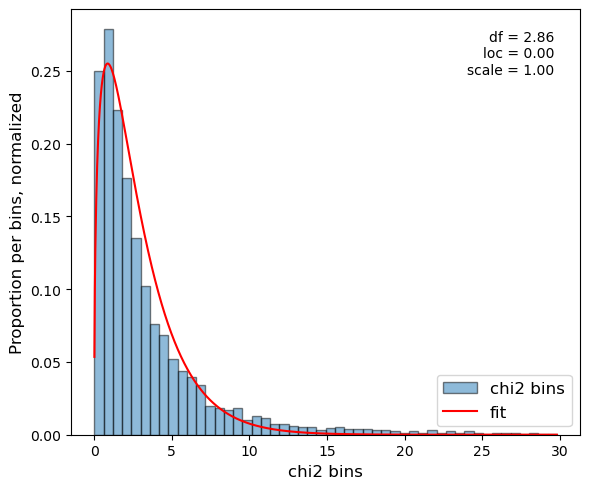

In [37]:
#--- Supposing a Chi2 dsitribution of the fitting parameter, compute the df of this distribution ---
import scipy.stats as stats

# fitting dist
chi_star = final[final["MOD_BEST"]==60]["CHI_BEST"]
chi_star = chi_star[chi_star<30]

df, loc, scale = stats.chi2.fit(chi_star, floc=0, fscale=1.0)
x = np.linspace(min(chi_star), max(chi_star), 1000)
pdf = stats.chi2.pdf(x, df, loc, scale)

# plot
plt.figure(figsize=(6,5))
plt.hist(chi_star, bins=50, density=True, alpha=0.5, edgecolor='black', label='chi2 bins')
plt.plot(x, pdf, 'r-', label='fit')

# add fit values
plt.text(0.95, 0.95,
    f"df = {df:.2f}\nloc = {loc:.2f}\nscale = {scale:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',)

#
# plt.ylim(0,1)
plt.xlabel("chi2 bins", fontsize = 12)
plt.ylabel("Proportion per bins, normalized", fontsize = 12)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()

